# Curate handscan patches for grid jobs

For each handscan class (**healthy** / **unhealthy** / **unique**):

1. Browse the full TPC image and choose a **plane** + **wire/tick crop**
2. Flip through the resulting **512×512** tiles and **discard** ones that do not represent the class
3. Save kept patches as job-ready NPZs and stage them to pnfs

**Output layout**

```text
/exp/sbnd/data/.../samples/handscan/curated/
  patches/{healthy,unhealthy,unique}/*.npz   # reco (1,1,512,512)
  manifests/{label}.jsonl
  session/{label}_state.json                     # resume crop + keep masks

/pnfs/.../inputs/handscan_curated/{label}/
/pnfs/.../lists/handscan_curated_{label,all}.list
```

Auto-generated full-plane crops (no patch curation) were relocated to
`archive/handscan_grid_auto_uncurated/` and `pnfs/.../inputs/_archived_handscan_grid_auto/`.

**Kernel:** `env`  
**Submit later:** `python inference/submit_handscan_grid.py --modes ddim2ddim --T 100 200`

In [3]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output, display

APP_ROOT = Path("/exp/sbnd/app/users/munjung/anomaly-detection")
sys.path.insert(0, str(APP_ROOT))
sys.path.insert(0, str(APP_ROOT / "samples"))

from configs.paths import (  # noqa: E402
    HANDSCAN_ARCHIVES,
    HANDSCAN_CURATED,
    HANDSCAN_GRID_AUTO_ARCHIVED,
    ensure_layout,
)
from handscan_patch_curation import (  # noqa: E402
    CLASS_SPECS,
    PATCH,
    PLANE_EDGES,
    PLANE_SCALES,
    clamp_crop_to_plane,
    extract_crop,
    load_records_for_class,
    load_waveform,
    plane_bounds,
    save_selected_patches,
    scale_crop,
    stage_to_pnfs,
    tile_patches,
    write_manifest,
)

ensure_layout()
HANDSCAN_CURATED.mkdir(parents=True, exist_ok=True)

ARCHIVE_JSONL = HANDSCAN_ARCHIVES / "offbeamlight_v10_06_00" / "unhealthy.jsonl"
OUT_ROOT = HANDSCAN_CURATED
PATCH_DIR = OUT_ROOT / "patches"
MANIFEST_DIR = OUT_ROOT / "manifests"
SESSION_DIR = OUT_ROOT / "session"
for d in (PATCH_DIR, MANIFEST_DIR, SESSION_DIR):
    d.mkdir(parents=True, exist_ok=True)

IMSHOW_KW = dict(aspect="auto", cmap="bwr", origin="lower", vmin=-15, vmax=15)

print("archive   ", ARCHIVE_JSONL, "exists=", ARCHIVE_JSONL.exists())
print("curated → ", OUT_ROOT)
print("archived auto-grid:", HANDSCAN_GRID_AUTO_ARCHIVED, "exists=", HANDSCAN_GRID_AUTO_ARCHIVED.exists())
for name in CLASS_SPECS:
    n = len(load_records_for_class(ARCHIVE_JSONL, name))
    print(f"  {name:10s}  n_events={n}")

archive    /exp/sbnd/data/users/munjung/anomaly-detection/archive/handscan_archives/offbeamlight_v10_06_00/unhealthy.jsonl exists= True
curated →  /exp/sbnd/data/users/munjung/anomaly-detection/samples/handscan/curated
archived auto-grid: /exp/sbnd/data/users/munjung/anomaly-detection/archive/handscan_grid_auto_uncurated exists= True
  healthy     n_events=21
  unhealthy   n_events=31
  unique      n_events=3


## Interactive curator

1. Pick a **class**, then step through events.
2. Choose **plane** and adjust **wire_lo / wire_hi** (and optional tick crop).
3. Click **Build patches**, then **Keep / Discard** while flipping tiles.
4. **Save kept patches** writes NPZs for this event and advances.

Session state (crop + keep mask) is stored under `session/` so you can resume.

**Tiling note:** non-overlapping 512×512 tiles. Only `floor(n_wires/512)×floor(n_ticks/512)` patches are made — extra wires/ticks on the high side of the crop are dropped. Prefer crop heights that are multiples of 512 (e.g. `[3000, 3512)` or `[3456, 3968)`) if you want full coverage of the region of interest.

In [4]:
class PatchCurator:
    def __init__(self, class_name: str = "healthy"):
        self.class_name = class_name
        self.records = load_records_for_class(ARCHIVE_JSONL, class_name)
        self.idx = 0
        self.waveform: np.ndarray | None = None
        self.patches: np.ndarray | None = None
        self.patch_meta: list[dict] = []
        self.keep: list[bool] = []
        self.patch_i = 0
        self.crop_params: dict = {}

        self.status = widgets.HTML()
        self.class_dd = widgets.Dropdown(
            options=list(CLASS_SPECS),
            value=class_name,
            description="class",
        )
        self.plane_dd = widgets.Dropdown(options=[0, 1, 2], value=1, description="plane")
        self.wire_lo = widgets.IntSlider(description="wire_lo", min=0, max=5637, step=1, continuous_update=False)
        self.wire_hi = widgets.IntSlider(description="wire_hi", min=1, max=5638, step=1, continuous_update=False)
        self.tick_lo = widgets.IntSlider(description="tick_lo", min=0, max=3426, step=1, value=0, continuous_update=False)
        self.tick_hi = widgets.IntSlider(description="tick_hi", min=1, max=3427, step=1, value=3427, continuous_update=False)
        self.use_full_ticks = widgets.Checkbox(value=True, description="full tick range")

        self.btn_prev = widgets.Button(description="◀ event", icon="arrow-left")
        self.btn_next = widgets.Button(description="event ▶", icon="arrow-right")
        self.btn_build = widgets.Button(description="Build patches", button_style="info", icon="th")
        self.btn_keep = widgets.Button(description="Keep (k)", button_style="success", icon="check")
        self.btn_discard = widgets.Button(description="Discard (d)", button_style="danger", icon="times")
        self.btn_prev_p = widgets.Button(description="◀ patch")
        self.btn_next_p = widgets.Button(description="patch ▶")
        self.btn_keep_all = widgets.Button(description="Keep all")
        self.btn_discard_all = widgets.Button(description="Discard all")
        self.btn_save = widgets.Button(description="Save kept patches", button_style="primary", icon="save")

        self.out_full = widgets.Output()
        self.out_patch = widgets.Output()

        self.class_dd.observe(self._on_class, names="value")
        self.plane_dd.observe(self._on_plane, names="value")
        self.btn_prev.on_click(lambda _: self.step_event(-1))
        self.btn_next.on_click(lambda _: self.step_event(+1))
        self.btn_build.on_click(lambda _: self.build_patches())
        self.btn_keep.on_click(lambda _: self.mark_keep(True))
        self.btn_discard.on_click(lambda _: self.mark_keep(False))
        self.btn_prev_p.on_click(lambda _: self.step_patch(-1))
        self.btn_next_p.on_click(lambda _: self.step_patch(+1))
        self.btn_keep_all.on_click(lambda _: self.set_all_keep(True))
        self.btn_discard_all.on_click(lambda _: self.set_all_keep(False))
        self.btn_save.on_click(lambda _: self.save_current())

        for w in (self.wire_lo, self.wire_hi, self.tick_lo, self.tick_hi, self.use_full_ticks):
            w.observe(self._on_crop_change, names="value")

        self.ui = widgets.VBox(
            [
                self.status,
                widgets.HBox([self.class_dd, self.plane_dd, self.btn_prev, self.btn_next, self.btn_build, self.btn_save]),
                widgets.HBox([self.wire_lo, self.wire_hi]),
                widgets.HBox([self.tick_lo, self.tick_hi, self.use_full_ticks]),
                self.out_full,
                widgets.HBox(
                    [self.btn_prev_p, self.btn_keep, self.btn_discard, self.btn_next_p, self.btn_keep_all, self.btn_discard_all]
                ),
                self.out_patch,
            ]
        )
        self._apply_class_defaults()
        self.load_event()

    # ── class / plane defaults ─────────────────────────────────────────────
    def _apply_class_defaults(self) -> None:
        spec = CLASS_SPECS[self.class_name]
        self.plane_dd.value = int(spec["default_plane"])
        self._sync_wire_sliders_to_plane()
        plo, phi = plane_bounds(int(self.plane_dd.value))
        dlo, dhi = spec["default_wire_lo"], spec["default_wire_hi"]
        if dlo is None or dhi is None:
            self.wire_lo.value, self.wire_hi.value = plo, phi
        else:
            self.wire_lo.value, self.wire_hi.value = clamp_crop_to_plane(int(self.plane_dd.value), dlo, dhi)

    def _sync_wire_sliders_to_plane(self) -> None:
        plo, phi = plane_bounds(int(self.plane_dd.value))
        self.wire_lo.min, self.wire_lo.max = plo, phi - 1
        self.wire_hi.min, self.wire_hi.max = plo + 1, phi

    def _on_class(self, change) -> None:
        self.class_name = change["new"]
        self.records = load_records_for_class(ARCHIVE_JSONL, self.class_name)
        self.idx = 0
        self._apply_class_defaults()
        self.load_event()

    def _on_plane(self, change) -> None:
        self._sync_wire_sliders_to_plane()
        plo, phi = plane_bounds(int(change["new"]))
        # Snap crop into the new plane (keep relative width if possible)
        width = max(1, self.wire_hi.value - self.wire_lo.value)
        self.wire_lo.value = plo
        self.wire_hi.value = min(phi, plo + width)
        self.render_full()

    def _on_crop_change(self, _=None) -> None:
        self.render_full()

    # ── session persistence ────────────────────────────────────────────────
    def _state_path(self) -> Path:
        sid = self.records[self.idx]["sample_id"].replace("/", "_").replace(":", "_")
        return SESSION_DIR / f"{self.class_name}__{sid}.json"

    def _load_session(self) -> None:
        p = self._state_path()
        if not p.is_file():
            return
        st = json.loads(p.read_text())
        self.plane_dd.value = int(st.get("plane_idx", self.plane_dd.value))
        self._sync_wire_sliders_to_plane()
        self.wire_lo.value = int(st.get("wire_lo", self.wire_lo.value))
        self.wire_hi.value = int(st.get("wire_hi", self.wire_hi.value))
        self.tick_lo.value = int(st.get("tick_lo", 0))
        self.tick_hi.value = int(st.get("tick_hi", self.waveform.shape[1] if self.waveform is not None else 3427))
        self.use_full_ticks.value = bool(st.get("use_full_ticks", True))
        if "keep" in st:
            self.keep = list(st["keep"])

    def _save_session(self) -> None:
        st = {
            "sample_id": self.records[self.idx]["sample_id"],
            "class": self.class_name,
            "plane_idx": int(self.plane_dd.value),
            "wire_lo": int(self.wire_lo.value),
            "wire_hi": int(self.wire_hi.value),
            "tick_lo": int(self.tick_lo.value),
            "tick_hi": int(self.tick_hi.value),
            "use_full_ticks": bool(self.use_full_ticks.value),
            "keep": list(self.keep),
            "n_patches": len(self.keep),
        }
        self._state_path().write_text(json.dumps(st, indent=2) + "\n")

    # ── event load / navigate ──────────────────────────────────────────────
    def step_event(self, delta: int) -> None:
        if not self.records:
            return
        self.idx = max(0, min(self.idx + delta, len(self.records) - 1))
        self.load_event()

    def load_event(self) -> None:
        if not self.records:
            self.status.value = f"<b>No records for class={self.class_name}</b>"
            return
        rec = self.records[self.idx]
        self.waveform = load_waveform(rec)
        self.tick_hi.max = self.waveform.shape[1]
        self.tick_lo.max = self.waveform.shape[1] - 1
        if self.use_full_ticks.value:
            self.tick_lo.value = 0
            self.tick_hi.value = self.waveform.shape[1]
        self.patches = None
        self.patch_meta = []
        self.keep = []
        self.patch_i = 0
        self._load_session()
        self.render_full()
        # Auto-build if session had a keep mask matching a prior tile count
        self.build_patches(restore_keep=True)

    # ── crop + tiles ──────────────────────────────────────────────────────
    def _crop_args(self) -> dict:
        plane = int(self.plane_dd.value)
        wlo, whi = clamp_crop_to_plane(plane, int(self.wire_lo.value), int(self.wire_hi.value))
        if self.use_full_ticks.value:
            tlo, thi = 0, int(self.waveform.shape[1])
        else:
            tlo = int(self.tick_lo.value)
            thi = max(tlo + 1, int(self.tick_hi.value))
        return dict(plane_idx=plane, wire_lo=wlo, wire_hi=whi, tick_lo=tlo, tick_hi=thi)

    def build_patches(self, restore_keep: bool = False) -> None:
        if self.waveform is None:
            return
        args = self._crop_args()
        self.crop_params = args
        crop = extract_crop(self.waveform, wire_lo=args["wire_lo"], wire_hi=args["wire_hi"], tick_lo=args["tick_lo"], tick_hi=args["tick_hi"])
        scaled = scale_crop(crop, args["plane_idx"])
        try:
            self.patches, self.patch_meta = tile_patches(scaled, PATCH)
        except ValueError as exc:
            self.status.value += f" <span style='color:#c0392b'>{exc}</span>"
            self.patches = None
            return
        prev_keep = list(self.keep) if restore_keep else []
        if restore_keep and len(prev_keep) == len(self.patch_meta):
            self.keep = prev_keep
        else:
            self.keep = [True] * len(self.patch_meta)
        self.patch_i = 0
        self.render_full()
        self.render_patch()
        self._update_status()

    # ── patch keep/discard ─────────────────────────────────────────────────
    def step_patch(self, delta: int) -> None:
        if not self.keep:
            return
        self.patch_i = max(0, min(self.patch_i + delta, len(self.keep) - 1))
        self.render_full()
        self.render_patch()

    def mark_keep(self, value: bool) -> None:
        if not self.keep:
            return
        self.keep[self.patch_i] = value
        self._save_session()
        if self.patch_i < len(self.keep) - 1:
            self.patch_i += 1
        self.render_full()
        self.render_patch()
        self._update_status()

    def set_all_keep(self, value: bool) -> None:
        self.keep = [value] * len(self.keep)
        self._save_session()
        self.render_patch()
        self._update_status()

    # ── rendering ──────────────────────────────────────────────────────────
    def _update_status(self) -> None:
        rec = self.records[self.idx]
        n_keep = sum(self.keep) if self.keep else 0
        n_tot = len(self.keep)
        self.status.value = (
            f"<b>[{self.idx + 1}/{len(self.records)}]</b> "
            f"<code>{rec['sample_id']}</code> &nbsp;|&nbsp; note=<i>{rec.get('note','')}</i> "
            f"&nbsp;|&nbsp; patches kept {n_keep}/{n_tot}"
        )

    def render_full(self) -> None:
        if self.waveform is None:
            return
        args = self._crop_args()
        with self.out_full:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(16, 4.2))
            ax0, ax1 = axes
            # Display transposed: x=wire, y=tick (matches HandscanUnhealthy)
            ax0.imshow(self.waveform.T, **IMSHOW_KW)
            for edge in PLANE_EDGES[1:-1]:
                ax0.axvline(edge, color="k", ls="--", lw=0.8)
            ax0.axvline(args["wire_lo"], color="lime", lw=1.2)
            ax0.axvline(args["wire_hi"], color="lime", lw=1.2)
            ax0.axhline(args["tick_lo"], color="lime", lw=1.0, ls=":")
            ax0.axhline(args["tick_hi"], color="lime", lw=1.0, ls=":")
            ax0.set_title("full TPC (ticks × wires)")
            ax0.set_xlabel("wire")
            ax0.set_ylabel("tick")

            crop = extract_crop(
                self.waveform,
                wire_lo=args["wire_lo"],
                wire_hi=args["wire_hi"],
                tick_lo=args["tick_lo"],
                tick_hi=args["tick_hi"],
            )
            ax1.imshow(crop.T, **IMSHOW_KW)
            if self.patches is not None and self.patch_meta:
                nh = max(m["iy"] for m in self.patch_meta) + 1
                nw = max(m["ix"] for m in self.patch_meta) + 1
                # After transpose: wire (iy) → x, tick (ix) → y
                for iy in range(1, nh):
                    ax1.axvline(iy * PATCH, color="k", lw=0.6, alpha=0.7)
                for ix in range(1, nw):
                    ax1.axhline(ix * PATCH, color="k", lw=0.6, alpha=0.7)
                if 0 <= self.patch_i < len(self.patch_meta):
                    m = self.patch_meta[self.patch_i]
                    from matplotlib.patches import Rectangle

                    ax1.add_patch(
                        Rectangle(
                            (m["y0"], m["x0"]),
                            PATCH,
                            PATCH,
                            fill=False,
                            edgecolor="yellow",
                            lw=2,
                        )
                    )
            ax1.set_title(
                f"crop plane={args['plane_idx']} wires=[{args['wire_lo']},{args['wire_hi']}) "
                f"ticks=[{args['tick_lo']},{args['tick_hi']})  scale={PLANE_SCALES[args['plane_idx']]}"
            )
            ax1.set_xlabel("wire (relative)")
            ax1.set_ylabel("tick (relative)")
            fig.tight_layout()
            display(fig)
            plt.close(fig)
        self._update_status()


    def render_patch(self) -> None:
        with self.out_patch:
            clear_output(wait=True)
            if self.patches is None or not len(self.patches):
                print("No patches — adjust crop and click Build patches.")
                return
            i = self.patch_i
            m = self.patch_meta[i]
            kept = self.keep[i]
            fig, ax = plt.subplots(figsize=(5, 5))
            # patches are already scaled to model units (~[-1,1] after /scale); show with tighter clim
            ax.imshow(self.patches[i].T, aspect="equal", cmap="bwr", origin="lower", vmin=-1, vmax=1)
            color = "#27ae60" if kept else "#c0392b"
            ax.set_title(
                f"patch {i + 1}/{len(self.patches)}  iy={m['iy']} ix={m['ix']}  "
                f"[{'KEEP' if kept else 'DISCARD'}]",
                color=color,
            )
            fig.tight_layout()
            display(fig)
            plt.close(fig)

    # ── save ───────────────────────────────────────────────────────────────
    def save_current(self) -> None:
        if self.patches is None or not self.keep or not any(self.keep):
            self.status.value += " <span style='color:#c0392b'>Nothing to save (keep ≥1 patch).</span>"
            return
        rec = self.records[self.idx]
        args = self.crop_params or self._crop_args()
        out_dir = PATCH_DIR / self.class_name
        # Remove previous patches for this sample_id under this class
        from handscan_patch_curation import safe_stem

        stem = safe_stem(rec["sample_id"])
        for old in out_dir.glob(f"{stem}_p*_y*_x*.npz"):
            old.unlink()
        rows = save_selected_patches(
            out_dir,
            rec,
            self.class_name,
            plane_idx=args["plane_idx"],
            wire_lo=args["wire_lo"],
            wire_hi=args["wire_hi"],
            tick_lo=args["tick_lo"],
            tick_hi=args["tick_hi"],
            patches=self.patches,
            patch_meta=self.patch_meta,
            keep_mask=self.keep,
        )
        self._save_session()
        self._append_manifest(rows)
        self.status.value += f" <span style='color:#27ae60'>Saved {len(rows)} patches.</span>"
        # Advance to next event
        if self.idx < len(self.records) - 1:
            self.step_event(+1)

    def _append_manifest(self, rows: list[dict]) -> None:
        man = MANIFEST_DIR / f"{self.class_name}.jsonl"
        existing = []
        if man.is_file():
            for line in man.read_text().splitlines():
                if not line.strip():
                    continue
                r = json.loads(line)
                # drop prior rows for this sample
                if r.get("sample_id") == rows[0]["sample_id"]:
                    continue
                existing.append(r)
        write_manifest(man, existing + rows)


curator = PatchCurator("healthy")
display(curator.ui)


TraitError: setting min > max

TraitError: setting min > max

TraitError: setting min > max

## Inventory of saved patches

In [5]:
rows = []
for label in ("healthy", "unhealthy", "unique"):
    d = PATCH_DIR / label
    n = len(list(d.glob("*.npz"))) if d.is_dir() else 0
    man = MANIFEST_DIR / f"{label}.jsonl"
    n_man = sum(1 for line in man.read_text().splitlines() if line.strip()) if man.is_file() else 0
    rows.append({"label": label, "npz_files": n, "manifest_rows": n_man, "dir": str(d)})
pd.DataFrame(rows)

,label,npz_files,manifest_rows,dir
0,healthy,96,96,/exp/sbnd/data/users/munjung/anomaly-detection...
1,unhealthy,79,79,/exp/sbnd/data/users/munjung/anomaly-detection...
2,unique,7,7,/exp/sbnd/data/users/munjung/anomaly-detection...


## Stage curated patches to pnfs (for jobsub)

Writes:
- `/pnfs/.../inputs/handscan_curated/{healthy,unhealthy,unique}/`
- `/pnfs/.../lists/handscan_curated_{healthy,unhealthy,unique,all}.list`

Then submit e.g.:

```bash
python inference/submit_handscan_grid.py --modes ddim2ddim --T 100 200
# or one class:
python inference/submit_handscan_grid.py --list handscan_curated_unhealthy.list --modes ddim2ddim --T 100 200
```

In [6]:
list_paths = stage_to_pnfs(OUT_ROOT)
for k, p in list_paths.items():
    n = sum(1 for line in p.read_text().splitlines() if line.strip())
    print(f"{k:10s}  n={n:4d}  → {p}")

healthy     n=  96  → /pnfs/sbnd/scratch/users/munjung/anomaly-detection/lists/handscan_curated_healthy.list
unhealthy   n=  79  → /pnfs/sbnd/scratch/users/munjung/anomaly-detection/lists/handscan_curated_unhealthy.list
unique      n=   7  → /pnfs/sbnd/scratch/users/munjung/anomaly-detection/lists/handscan_curated_unique.list
all         n= 182  → /pnfs/sbnd/scratch/users/munjung/anomaly-detection/lists/handscan_curated_all.list


## Quick visual check of a saved patch NPZ

unique: 7 patches
{'reco': (1, 1, 512, 512), 'source_file': (), 'patch_iy': (), 'patch_ix': (), 'frame': (), 'label': (), 'wire_lo': (), 'wire_hi': (), 'tick_lo': (), 'tick_hi': (), 'plane_idx': (), 'scale': (), 'sample_id': (), 'note': ()}


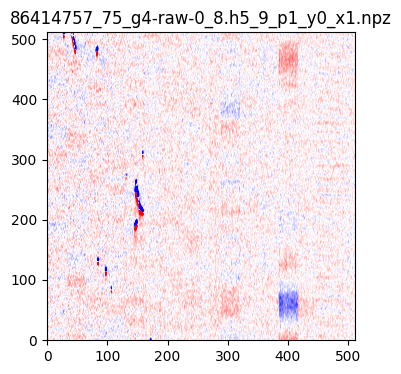

In [18]:
label = "unique"  # edit
files = sorted((PATCH_DIR / label).glob("*.npz"))
print(f"{label}: {len(files)} patches")
if files:
    z = np.load(files[1], allow_pickle=True)
    print({k: z[k].shape if hasattr(z[k], "shape") else z[k] for k in z.files})
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(z["reco"][0, 0].T, aspect="equal", cmap="bwr", origin="lower", vmin=-0.1, vmax=0.1)
    ax.set_title(files[0].name)
    plt.show()
